# Handling Outliers

### Z-score

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.impute import SimpleImputer as si

In [2]:
df_out = pd.read_csv('scholarship.csv')

In [3]:
df_out.head()

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0


C:\Users\MISHAL MITTAL\AppData\Local\Temp\ipykernel_17820\2561974299.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_out['semester_percentage'])
C:\Users\MISHAL MITTAL\AppData\Local\Temp\ipykernel_17820\2561974299.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_out['scholarship_exa

<Axes: xlabel='scholarship_exam_marks', ylabel='Density'>

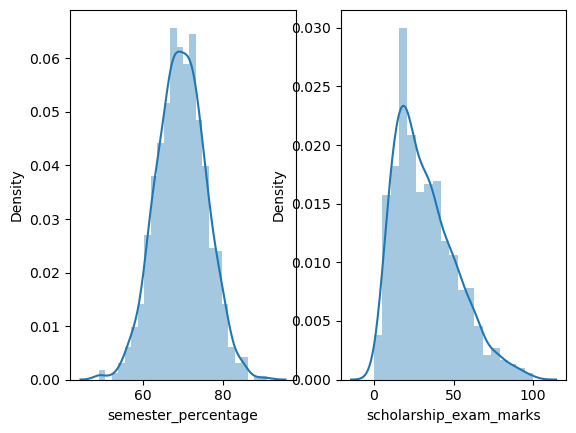

In [4]:
plt.subplot(1,2,1)
sns.distplot(df_out['semester_percentage'])

plt.subplot(1,2,2)
sns.distplot(df_out['scholarship_exam_marks'])

<Axes: ylabel='semester_percentage'>

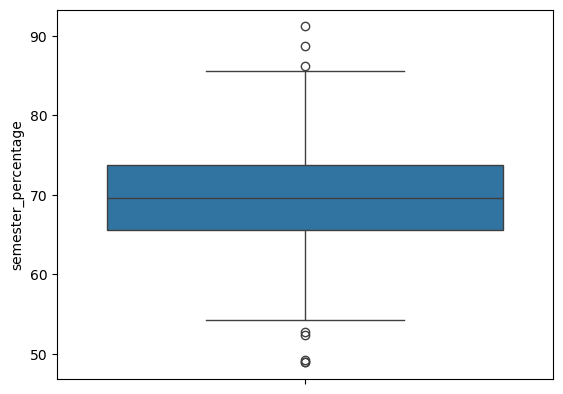

In [5]:
sns.boxplot(df_out['semester_percentage'])

In [6]:
mean = df_out['semester_percentage'].mean()
std = df_out['semester_percentage'].std()

print(mean,',' ,std)

69.6124 , 6.158978751323897


In [7]:
df_out['z-score'] = (df_out['semester_percentage'] - mean)/std
df_out

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371
...,...,...,...,...
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
998,86.2,46,1,2.693239


In [8]:
df_out[(df_out['z-score'] > 3) | (df_out['z-score'] < -3)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
485,49.2,44,1,-3.314251
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
999,49.0,10,1,-3.346724


### Trimming

In [9]:
df_out1 = df_out.copy()

In [10]:
df_out1[(df_out1['z-score'] > 3) | (df_out1['z-score'] < -3)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
485,49.2,44,1,-3.314251
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
999,49.0,10,1,-3.346724


In [11]:
df_out1 = df_out1[(df_out1['z-score'] < 3) & (df_out1['z-score'] > -3)]

In [12]:
df_out1.shape

(995, 4)

<Axes: ylabel='semester_percentage'>

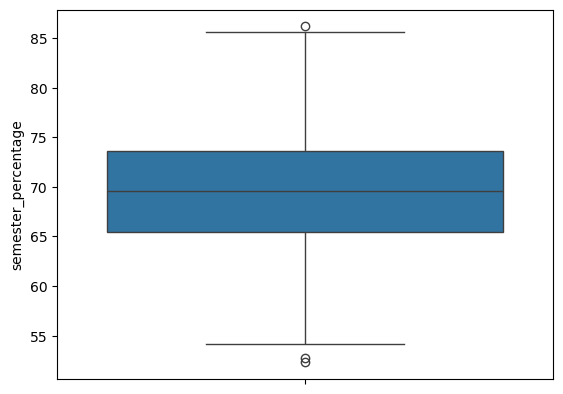

In [13]:
sns.boxplot(df_out1['semester_percentage'])

### Capping


In [14]:
df_out2 = df_out.copy()

In [15]:
max_limit = mean + 3 * std
min_limit = mean - 3* std
print(max_limit , ',' , min_limit)

88.08933625397168 , 51.13546374602831


In [16]:
df_out2[(df_out2['semester_percentage'] > max_limit) | (df_out2['semester_percentage'] < min_limit)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
485,49.2,44,1,-3.314251
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
999,49.0,10,1,-3.346724


In [17]:
df_out2['semester_percentage'] = np.where(df_out2['semester_percentage'] > max_limit, max_limit ,
                                         (np.where(df_out2['semester_percentage'] < min_limit , min_limit, df_out2['semester_percentage'])))

In [18]:
df_out2[(df_out2['semester_percentage'] > max_limit) | (df_out2['semester_percentage'] < min_limit)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score


In [19]:
df_out2.shape

(1000, 4)

<Axes: ylabel='semester_percentage'>

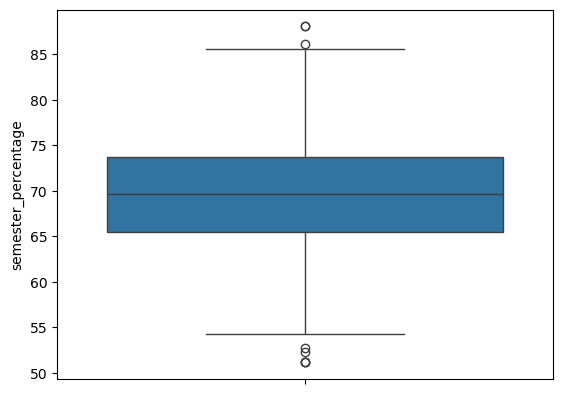

In [21]:
sns.boxplot(df_out2['semester_percentage'])

C:\Users\MISHAL MITTAL\AppData\Local\Temp\ipykernel_17820\3236844733.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_out['semester_percentage'])
C:\Users\MISHAL MITTAL\AppData\Local\Temp\ipykernel_17820\3236844733.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_out2['semester_perce

<Axes: ylabel='semester_percentage'>

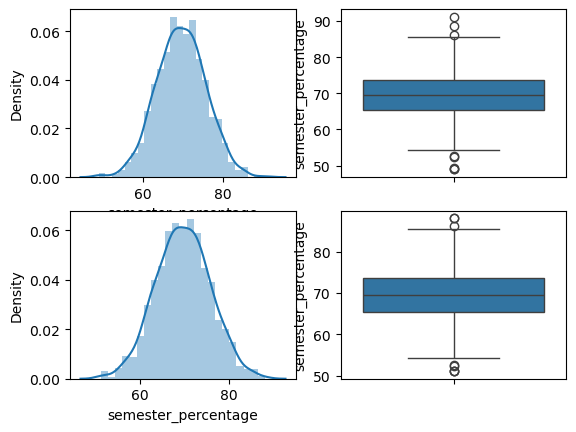

In [22]:
plt.subplot(2,2,1)
sns.distplot(df_out['semester_percentage'])

plt.subplot(2,2,2)
sns.boxplot(df_out['semester_percentage'])

plt.subplot(2,2,3)
sns.distplot(df_out2['semester_percentage'])

plt.subplot(2,2,4)
sns.boxplot(df_out2['semester_percentage'])